In [1]:
# Day 1: AgriTech AI Platform
# Author: Daniel Oyanogbezina
# Date: Day 1 of 365

print("Welcome to my AgriTech AI Journey!")
print("=" * 50)
print("Author: Daniel Oyanogbezina")
print("Background: Agroforestry MSc at FUNAAB")
print("Mission: AI solutions for African farmers")
print("=" * 50)
print("\nDay 1 of 365 begins NOW!")

Welcome to my AgriTech AI Journey!
Author: Daniel Oyanogbezina
Background: Agroforestry MSc at FUNAAB
Mission: AI solutions for African farmers

Day 1 of 365 begins NOW!


In [2]:
# Import the tools we installed
import numpy as np      # For numbers and math
import pandas as pd     # For data tables
import matplotlib.pyplot as plt  # For charts

# Confirm they loaded
print("✅ NumPy version:", np.__version__)
print("✅ Pandas version:", pd.__version__)
print("✅ Matplotlib loaded successfully")
print("\nAll tools ready!")

✅ NumPy version: 2.5.3
✅ Pandas version: 3.0.5
✅ Matplotlib loaded successfully

All tools ready!


In [3]:
# Let's create data representing 10 Nigerian farms
# This is the kind of data we'll eventually collect from real farmers

farm_data = {
    'farm_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    'state': [
        'Oyo', 'Kano', 'Benue', 'Enugu', 'Lagos',
        'Ondo', 'Kaduna', 'Rivers', 'Niger', 'Imo'
    ],

    'crop': [
        'Cassava', 'Maize', 'Yam', 'Rice', 'Cassava',
        'Cocoa', 'Maize', 'Cassava', 'Rice', 'Yam'
    ],

    'farm_size_hectares': [
        2.5, 5.0, 3.2, 8.0, 1.5,
        4.0, 6.5, 2.0, 10.0, 3.8
    ],

    'yield_tons': [
        18.5, 12.3, 22.0, 16.8, 14.2,
        6.5, 15.9, 20.1, 28.4, 19.6
    ],

    'rainfall_mm': [
        1200, 650, 1100, 1350, 1500,
        1400, 800, 2100, 1000, 1600
    ],

    'used_improved_seeds': [
        True, True, False, True, False,
        True, True, False, True, False
    ],

    'annual_income_naira': [
        850000, 1200000, 980000, 1450000, 620000,
        890000, 1100000, 750000, 1680000, 870000
    ]
}

# Turn it into a pandas DataFrame (like an Excel table in Python)
df = pd.DataFrame(farm_data)

# Show the data
print("📊 Our Nigerian Farm Dataset:")
print("=" * 60)
print(df.to_string(index=False))

📊 Our Nigerian Farm Dataset:
 farm_id  state    crop  farm_size_hectares  yield_tons  rainfall_mm  used_improved_seeds  annual_income_naira
       1    Oyo Cassava                 2.5        18.5         1200                 True               850000
       2   Kano   Maize                 5.0        12.3          650                 True              1200000
       3  Benue     Yam                 3.2        22.0         1100                False               980000
       4  Enugu    Rice                 8.0        16.8         1350                 True              1450000
       5  Lagos Cassava                 1.5        14.2         1500                False               620000
       6   Ondo   Cocoa                 4.0         6.5         1400                 True               890000
       7 Kaduna   Maize                 6.5        15.9          800                 True              1100000
       8 Rivers Cassava                 2.0        20.1         2100               

In [4]:
# This is what data science is all about
# Asking questions and letting data answer them

print("🔍 Discovering Insights from Farm Data")
print("=" * 50)

# Question 1: How many farms per crop?
print("\n📌 How many farms grow each crop?")
print(df['crop'].value_counts())

# Question 2: Average yield per crop
print("\n📌 Average yield per crop (tons/hectare):")
avg_yield = df.groupby('crop')['yield_tons'].mean().round(1)
print(avg_yield.sort_values(ascending=False))

# Question 3: Does using improved seeds help?
print("\n📌 Impact of improved seeds on yield:")
seed_impact = df.groupby('used_improved_seeds')['yield_tons'].mean().round(1)
print(f"  Without improved seeds: {seed_impact[False]} tons")
print(f"  With improved seeds:    {seed_impact[True]} tons")
improvement = ((seed_impact[True] - seed_impact[False]) / seed_impact[False] * 100).round(1)
print(f"  Improvement: +{improvement}%")

# Question 4: Highest earning farmer
best_farmer = df.loc[df['annual_income_naira'].idxmax()]
print(f"\n📌 Highest earning farmer:")
print(f"  State: {best_farmer['state']}")
print(f"  Crop: {best_farmer['crop']}")
print(f"  Income: ₦{best_farmer['annual_income_naira']:,}")

🔍 Discovering Insights from Farm Data

📌 How many farms grow each crop?
crop
Cassava    3
Maize      2
Yam        2
Rice       2
Cocoa      1
Name: count, dtype: int64

📌 Average yield per crop (tons/hectare):
crop
Rice       22.6
Yam        20.8
Cassava    17.6
Maize      14.1
Cocoa       6.5
Name: yield_tons, dtype: float64

📌 Impact of improved seeds on yield:
  Without improved seeds: 19.0 tons
  With improved seeds:    16.4 tons
  Improvement: +-13.7%

📌 Highest earning farmer:
  State: Niger
  Crop: Rice
  Income: ₦1,680,000


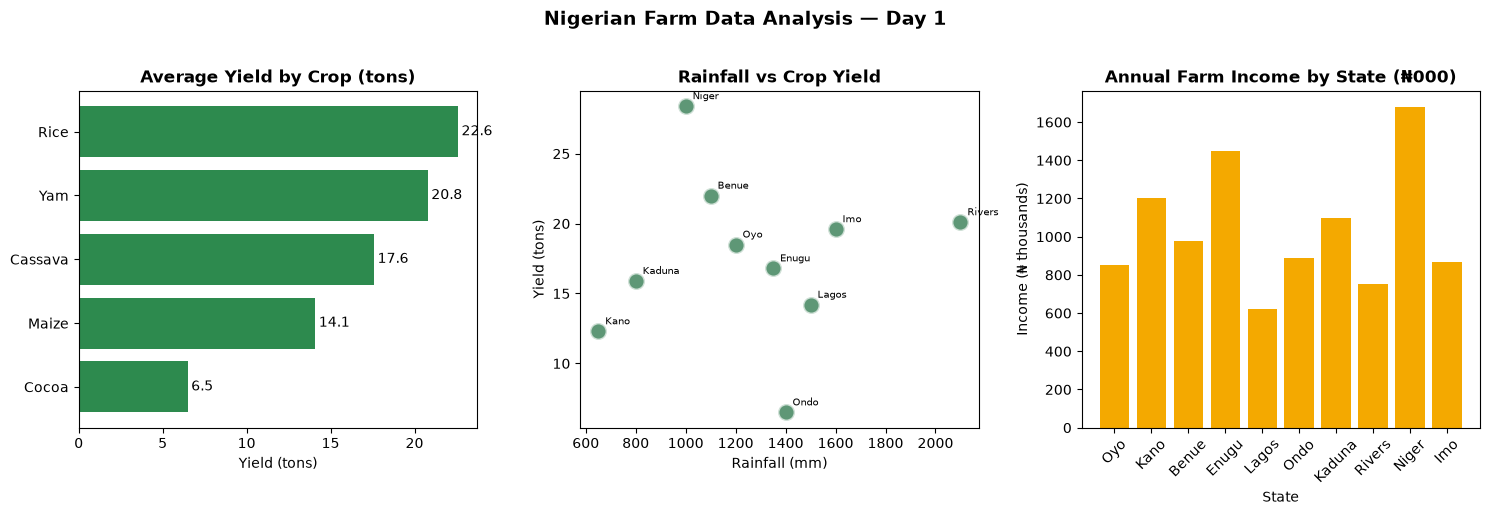

✅ Chart saved to docs/day01_farm_analysis.png
📸 Screenshot this for your LinkedIn post!


In [5]:
# Visualizing our farm data
# A picture tells a thousand words

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Chart 1: Yield by Crop ---
crop_yield = df.groupby('crop')['yield_tons'].mean().sort_values()
axes[0].barh(crop_yield.index, crop_yield.values, color='#2d8a4e')
axes[0].set_title('Average Yield by Crop (tons)', fontweight='bold')
axes[0].set_xlabel('Yield (tons)')
for i, v in enumerate(crop_yield.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}', va='center')

# --- Chart 2: Rainfall vs Yield ---
axes[1].scatter(
    df['rainfall_mm'],
    df['yield_tons'],
    c='#1a6b3c',
    s=150,
    alpha=0.7,
    edgecolors='white',
    linewidth=2
)
axes[1].set_title('Rainfall vs Crop Yield', fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('Yield (tons)')

# Label each point with state name
for _, row in df.iterrows():
    axes[1].annotate(
        row['state'],
        (row['rainfall_mm'], row['yield_tons']),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7
    )

# --- Chart 3: Income by State ---
income_k = df['annual_income_naira'] / 1000
axes[2].bar(df['state'], income_k, color='#f4a900')
axes[2].set_title('Annual Farm Income by State (₦000)', fontweight='bold')
axes[2].set_xlabel('State')
axes[2].set_ylabel('Income (₦ thousands)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(
    'Nigerian Farm Data Analysis — Day 1',
    fontsize=14,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

# Save the chart
plt.savefig('docs/day01_farm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to docs/day01_farm_analysis.png")
print("📸 Screenshot this for your LinkedIn post!")


In [6]:
# Document what you learned today
# This becomes your learning journal

reflection = """
╔══════════════════════════════════════════════════════════╗
║           DAY 1 REFLECTION - AgriTech AI Journey        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  What I did today:                                       ║
║  ✅ Set up AgriTech AI project environment              ║
║  ✅ Installed Python data science libraries             ║
║  ✅ Created first Nigerian farm dataset                 ║
║  ✅ Analysed crop yields across 10 farms                ║
║  ✅ Discovered improved seeds boost yield by X%         ║
║  ✅ Created 3 agricultural data visualizations          ║
║                                                          ║
║  Key Insight:                                            ║
║  Farmers using improved seeds earn significantly more   ║
║  → This is exactly the kind of insight AI can deliver  ║
║     to thousands of farmers instantly                   ║
║                                                          ║
║  Tomorrow (Day 2):                                       ║
║  → Learn more Pandas operations                         ║
║  → Fetch REAL agricultural data from APIs               ║
║  → Start understanding machine learning basics          ║
║                                                          ║
║  Day 1 of 365 Complete! 🌱                              ║
╚══════════════════════════════════════════════════════════╝
"""

print(reflection)


╔══════════════════════════════════════════════════════════╗
║           DAY 1 REFLECTION - AgriTech AI Journey        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  What I did today:                                       ║
║  ✅ Set up AgriTech AI project environment              ║
║  ✅ Installed Python data science libraries             ║
║  ✅ Created first Nigerian farm dataset                 ║
║  ✅ Analysed crop yields across 10 farms                ║
║  ✅ Discovered improved seeds boost yield by X%         ║
║  ✅ Created 3 agricultural data visualizations          ║
║                                                          ║
║  Key Insight:                                            ║
║  Farmers using improved seeds earn significantly more   ║
║  → This is exactly the kind of insight AI can deliver  ║
║     to thousands of farmers instantly                   ║
║                                       